In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)

In [2]:
BASE_DIR = Path("..")
RAW_DIR = BASE_DIR / "data" / "raw"

vehicles = pd.read_csv(RAW_DIR / "vehicles.csv")
telematics = pd.read_csv(RAW_DIR / "telematics.csv")
service_history = pd.read_csv(RAW_DIR / "service_history.csv")
support_tickets = pd.read_csv(RAW_DIR / "support_tickets.csv")
failure_labels = pd.read_csv(RAW_DIR / "failure_labels.csv")

telematics["date"] = pd.to_datetime(telematics["date"])
service_history["service_date"] = pd.to_datetime(service_history["service_date"])
support_tickets["ticket_date"] = pd.to_datetime(support_tickets["ticket_date"])

In [3]:
datasets = {
    "vehicles": vehicles,
    "telematics": telematics,
    "service_history": service_history,
    "support_tickets": support_tickets,
    "failure_labels": failure_labels
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("Shape:", df.shape)
    print("Missing values:")
    print(df.isna().sum())


vehicles
Shape: (3000, 8)
Missing values:
vehicle_id     0
customer_id    0
model          0
year           0
fuel_type      0
industry       0
mileage        0
vehicle_age    0
dtype: int64

telematics
Shape: (360000, 8)
Missing values:
vehicle_id         0
date               0
engine_temp        0
oil_pressure       0
battery_voltage    0
brake_events       0
idle_hours         0
daily_miles        0
dtype: int64

service_history
Shape: (9500, 4)
Missing values:
vehicle_id      0
service_date    0
repair_type     0
repair_cost     0
dtype: int64

support_tickets
Shape: (4721, 5)
Missing values:
ticket_id         0
vehicle_id        0
ticket_date       0
complaint_text    0
priority          0
dtype: int64

failure_labels
Shape: (3000, 3)
Missing values:
vehicle_id                  0
failure_probability_true    0
failure_next_30_days        0
dtype: int64


In [7]:
print("Duplicate vehicle IDs:", vehicles["vehicle_id"].duplicated().sum())
print("Duplicate failure labels:", failure_labels["vehicle_id"].duplicated().sum())

print("\nTelematics date range:")
print(telematics["date"].min(), "to", telematics["date"].max())

print("\nService date range:")
print(service_history["service_date"].min(), "to", service_history["service_date"].max())

print("\nTicket date range:")
print(support_tickets["ticket_date"].min(), "to", support_tickets["ticket_date"].max())

Duplicate vehicle IDs: 0
Duplicate failure labels: 0

Telematics date range:
2026-01-01 00:00:00 to 2026-04-30 00:00:00

Service date range:
2026-01-01 00:00:00 to 2026-04-30 00:00:00

Ticket date range:
2026-01-01 00:00:00 to 2026-04-30 00:00:00


In [8]:
failure_rate = failure_labels["failure_next_30_days"].mean()
print(f"Failure rate: {failure_rate:.2%}")

failure_labels["failure_next_30_days"].value_counts(normalize=True)

Failure rate: 25.00%


failure_next_30_days
0    0.75
1    0.25
Name: proportion, dtype: float64

In [ ]:
import seaborn as sns
sns.__version__

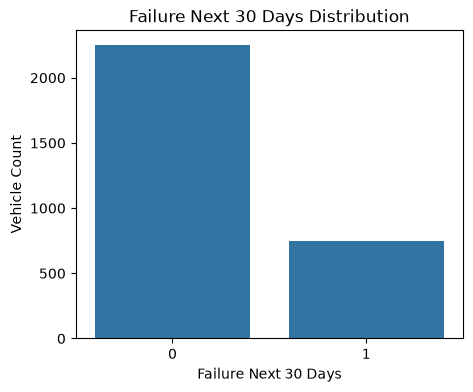

In [4]:
plt.figure(figsize=(5,4))
sns.countplot(data=failure_labels, x="failure_next_30_days")
plt.title("Failure Next 30 Days Distribution")
plt.xlabel("Failure Next 30 Days")
plt.ylabel("Vehicle Count")
plt.show()

In [5]:
vehicles.describe()

,year,mileage,vehicle_age
count,3000.000000,3000.000000,3000.000000
mean,2020.525333,92872.318333,5.474667
std,2.878215,50698.217693,2.878215
min,2016.000000,5005.000000,1.000000
25%,2018.000000,48788.750000,3.000000
50%,2021.000000,94205.500000,5.000000
75%,2023.000000,137008.750000,8.000000
max,2025.000000,179946.000000,10.000000


In [6]:
failure_labels.head()

,vehicle_id,failure_probability_true,failure_next_30_days
0,V00001,0.927117,1
1,V00002,0.723535,0
2,V00003,0.911447,1
3,V00004,0.839943,0
4,V00005,0.704477,0


In [7]:
telematics.head()

,vehicle_id,date,engine_temp,oil_pressure,battery_voltage,brake_events,idle_hours,daily_miles
0,V00001,2026-01-01,93.350917,45.000877,12.134309,14,2.109864,69.096891
1,V00001,2026-01-02,97.449228,38.693877,12.657129,14,3.960258,31.999626
2,V00001,2026-01-03,99.705683,40.971823,12.256879,11,3.203803,66.622525
3,V00001,2026-01-04,96.828207,43.343437,12.079806,14,0.845895,71.984592
4,V00001,2026-01-05,94.173519,36.219813,12.477579,12,3.079657,104.067379


In [8]:
support_tickets.head()

,ticket_id,vehicle_id,ticket_date,complaint_text,priority
0,T000001,V00001,2026-04-24,Oil pressure warning triggered,High
1,T000002,V00005,2026-01-17,No major issue reported,Medium
2,T000003,V00007,2026-01-05,Reduced acceleration reported,Low
3,T000004,V00007,2026-01-31,Oil pressure warning triggered,High
4,T000005,V00007,2026-04-22,No major issue reported,Medium


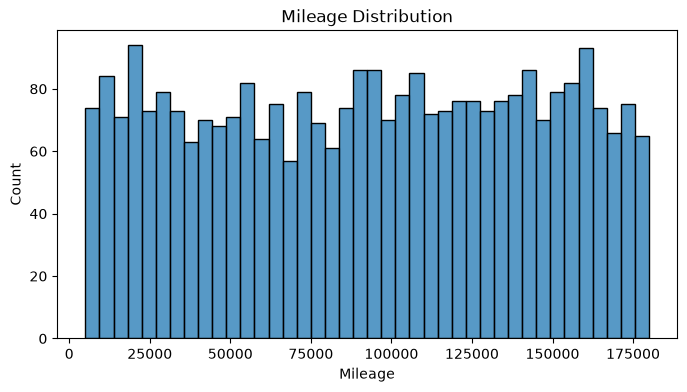

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(vehicles["mileage"], bins=40)
plt.title("Mileage Distribution")
plt.xlabel("Mileage")
plt.show()

In [10]:
vehicle_label_df = vehicles.merge(failure_labels, on="vehicle_id", how="left")

vehicle_label_df.head()

,vehicle_id,customer_id,model,year,fuel_type,industry,mileage,vehicle_age,failure_probability_true,failure_next_30_days
0,V00001,C0103,Transit,2018,Hybrid,Construction,125198,8,0.927117,1
1,V00002,C0436,F-150,2020,Gasoline,Government,79155,6,0.723535,0
2,V00003,C0349,Maverick,2020,Electric,Utilities,126449,6,0.911447,1
3,V00004,C0271,F-150,2021,Diesel,Delivery,81700,5,0.839943,0
4,V00005,C0107,Super Duty,2022,Hybrid,Utilities,11955,4,0.704477,0


In [11]:
failure_by_model = (
    vehicle_label_df
    .groupby("model")["failure_next_30_days"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

failure_by_model

,model,failure_next_30_days
0,Super Duty,0.279412
1,E-Transit,0.251256
2,F-150,0.247803
3,Maverick,0.244698
4,Transit,0.226601


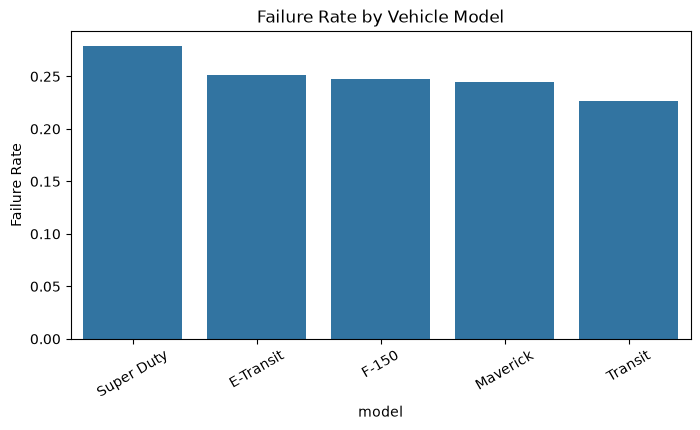

In [12]:
plt.figure(figsize=(8,4))
sns.barplot(data=failure_by_model, x="model", y="failure_next_30_days")
plt.title("Failure Rate by Vehicle Model")
plt.ylabel("Failure Rate")
plt.xticks(rotation=30)
plt.show()

In [13]:
failure_by_industry = (
    vehicle_label_df
    .groupby("industry")["failure_next_30_days"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

failure_by_industry

,industry,failure_next_30_days
0,Utilities,0.273666
1,Construction,0.261460
2,Logistics,0.257496
3,Delivery,0.244767
4,Government,0.216511


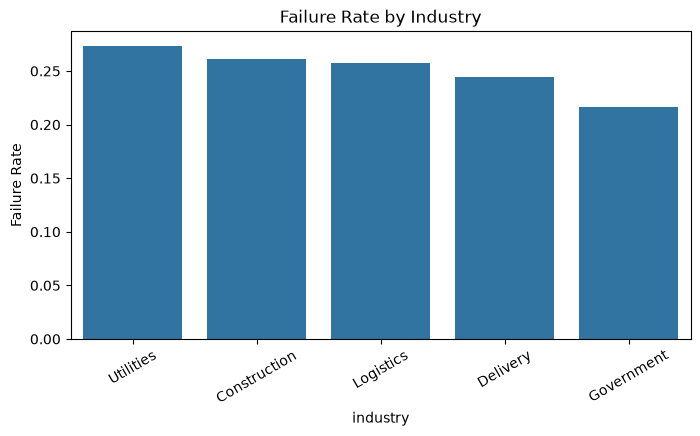

In [14]:
plt.figure(figsize=(8,4))
sns.barplot(data=failure_by_industry, x="industry", y="failure_next_30_days")
plt.title("Failure Rate by Industry")
plt.ylabel("Failure Rate")
plt.xticks(rotation=30)
plt.show()

In [15]:
telematics_agg = telematics.groupby("vehicle_id").agg(
    avg_engine_temp=("engine_temp", "mean"),
    max_engine_temp=("engine_temp", "max"),
    avg_oil_pressure=("oil_pressure", "mean"),
    min_oil_pressure=("oil_pressure", "min"),
    avg_battery_voltage=("battery_voltage", "mean"),
    min_battery_voltage=("battery_voltage", "min"),
    total_brake_events=("brake_events", "sum"),
    avg_idle_hours=("idle_hours", "mean"),
    total_daily_miles=("daily_miles", "sum")
).reset_index()

eda_df = vehicle_label_df.merge(telematics_agg, on="vehicle_id", how="left")
eda_df.head()

,vehicle_id,customer_id,model,year,fuel_type,industry,mileage,vehicle_age,failure_probability_true,failure_next_30_days,avg_engine_temp,max_engine_temp,avg_oil_pressure,min_oil_pressure,avg_battery_voltage,min_battery_voltage,total_brake_events,avg_idle_hours,total_daily_miles
0,V00001,C0103,Transit,2018,Hybrid,Construction,125198,8,0.927117,1,94.481981,106.062108,37.074801,30.344797,12.449984,11.677264,1404,2.757003,9068.657408
1,V00002,C0436,F-150,2020,Gasoline,Government,79155,6,0.723535,0,91.018243,107.257515,37.661517,31.008005,12.388175,11.593240,1301,2.516825,8939.342723
2,V00003,C0349,Maverick,2020,Electric,Utilities,126449,6,0.911447,1,95.316620,109.442020,42.522175,35.623743,12.183761,11.465695,1249,2.494917,9182.822235
3,V00004,C0271,F-150,2021,Diesel,Delivery,81700,5,0.839943,0,91.501110,103.218983,39.306578,32.239884,12.798029,12.110949,1188,2.584004,8950.084504
4,V00005,C0107,Super Duty,2022,Hybrid,Utilities,11955,4,0.704477,0,85.104323,100.018771,41.404147,32.894843,12.503618,11.908163,1149,2.517821,8841.422327


In [16]:
sensor_cols = [
    "avg_engine_temp",
    "max_engine_temp",
    "avg_oil_pressure",
    "min_oil_pressure",
    "avg_battery_voltage",
    "min_battery_voltage",
    "total_brake_events",
    "avg_idle_hours",
    "total_daily_miles"
]

eda_df.groupby("failure_next_30_days")[sensor_cols].mean().T

failure_next_30_days,0,1
avg_engine_temp,90.645466,94.460150
max_engine_temp,103.510001,107.217686
avg_oil_pressure,41.182197,38.780163
min_oil_pressure,33.471372,31.123312
avg_battery_voltage,12.367080,12.218276
min_battery_voltage,11.596396,11.443394
total_brake_events,1190.121333,1320.618667
avg_idle_hours,2.485006,2.753254
total_daily_miles,9001.402851,8991.682564


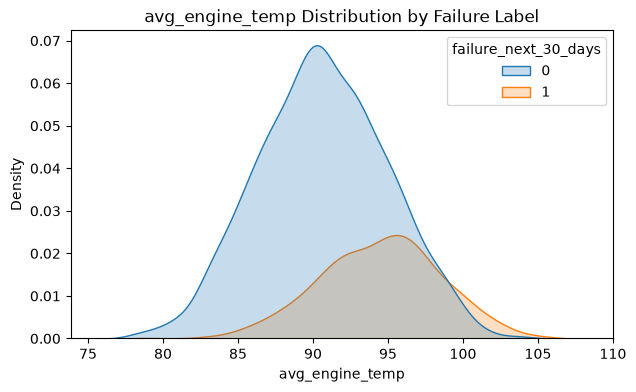

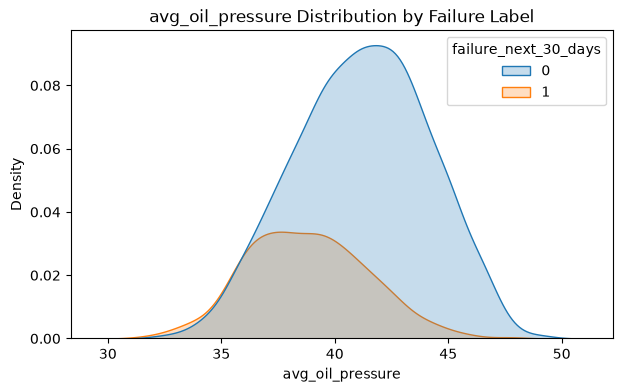

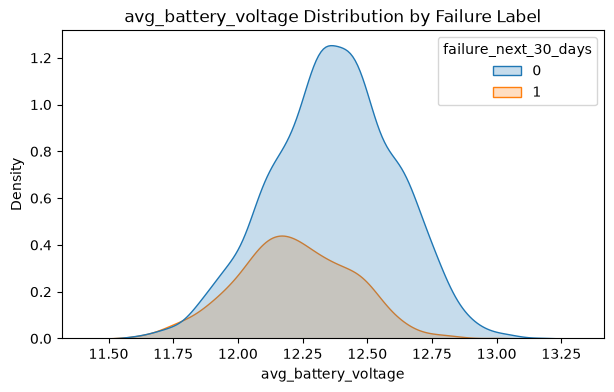

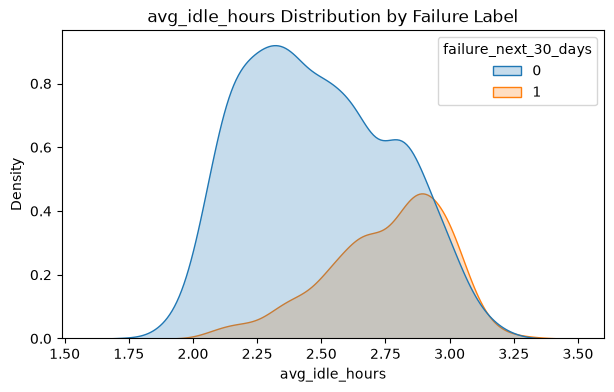

In [17]:
for col in ["avg_engine_temp", "avg_oil_pressure", "avg_battery_voltage", "avg_idle_hours"]:
    plt.figure(figsize=(7,4))
    sns.kdeplot(data=eda_df, x=col, hue="failure_next_30_days", fill=True)
    plt.title(f"{col} Distribution by Failure Label")
    plt.show()

In [18]:
service_agg = service_history.groupby("vehicle_id").agg(
    repair_count=("repair_type", "count"),
    total_repair_cost=("repair_cost", "sum"),
    avg_repair_cost=("repair_cost", "mean"),
    last_service_date=("service_date", "max")
).reset_index()

service_agg["days_since_last_service"] = (
    telematics["date"].max() - service_agg["last_service_date"]
).dt.days

eda_df = eda_df.merge(service_agg, on="vehicle_id", how="left")

for col in ["repair_count", "total_repair_cost", "avg_repair_cost", "days_since_last_service"]:
    eda_df[col] = eda_df[col].fillna(0)

eda_df.head()

,vehicle_id,customer_id,model,year,fuel_type,industry,mileage,vehicle_age,failure_probability_true,failure_next_30_days,avg_engine_temp,max_engine_temp,avg_oil_pressure,min_oil_pressure,avg_battery_voltage,min_battery_voltage,total_brake_events,avg_idle_hours,total_daily_miles,repair_count,total_repair_cost,avg_repair_cost,last_service_date,days_since_last_service
0,V00001,C0103,Transit,2018,Hybrid,Construction,125198,8,0.927117,1,94.481981,106.062108,37.074801,30.344797,12.449984,11.677264,1404,2.757003,9068.657408,2.0,371.98,185.9900,2026-02-20,69.0
1,V00002,C0436,F-150,2020,Gasoline,Government,79155,6,0.723535,0,91.018243,107.257515,37.661517,31.008005,12.388175,11.593240,1301,2.516825,8939.342723,4.0,2547.91,636.9775,2026-04-19,11.0
2,V00003,C0349,Maverick,2020,Electric,Utilities,126449,6,0.911447,1,95.316620,109.442020,42.522175,35.623743,12.183761,11.465695,1249,2.494917,9182.822235,3.0,697.47,232.4900,2026-02-17,72.0
3,V00004,C0271,F-150,2021,Diesel,Delivery,81700,5,0.839943,0,91.501110,103.218983,39.306578,32.239884,12.798029,12.110949,1188,2.584004,8950.084504,1.0,548.91,548.9100,2026-04-22,8.0
4,V00005,C0107,Super Duty,2022,Hybrid,Utilities,11955,4,0.704477,0,85.104323,100.018771,41.404147,32.894843,12.503618,11.908163,1149,2.517821,8841.422327,5.0,3909.95,781.9900,2026-04-30,0.0


In [19]:
eda_df.groupby("failure_next_30_days")[["repair_count", "total_repair_cost", "days_since_last_service"]].mean()

,repair_count,total_repair_cost,days_since_last_service
failure_next_30_days,,,
0,2.699556,1377.477587,32.417333
1,4.568000,2394.525147,24.452000


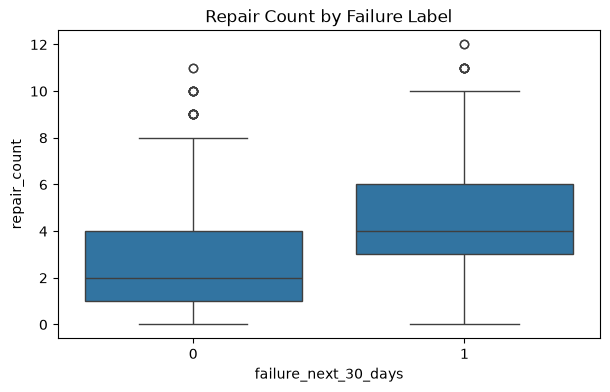

In [20]:
plt.figure(figsize=(7,4))
sns.boxplot(data=eda_df, x="failure_next_30_days", y="repair_count")
plt.title("Repair Count by Failure Label")
plt.show()

In [21]:
ticket_agg = support_tickets.groupby("vehicle_id").agg(
    ticket_count=("ticket_id", "count"),
    high_priority_tickets=("priority", lambda x: (x == "High").sum())
).reset_index()

eda_df = eda_df.merge(ticket_agg, on="vehicle_id", how="left")

eda_df["ticket_count"] = eda_df["ticket_count"].fillna(0)
eda_df["high_priority_tickets"] = eda_df["high_priority_tickets"].fillna(0)

eda_df.groupby("failure_next_30_days")[["ticket_count", "high_priority_tickets"]].mean()

,ticket_count,high_priority_tickets
failure_next_30_days,,
0,1.376444,0.406667
1,2.165333,0.856000


In [22]:
high_risk_preview = eda_df.sort_values(
    by=["high_priority_tickets", "avg_engine_temp", "repair_count"],
    ascending=False
)[[
    "vehicle_id",
    "model",
    "industry",
    "mileage",
    "vehicle_age",
    "avg_engine_temp",
    "avg_oil_pressure",
    "repair_count",
    "ticket_count",
    "high_priority_tickets",
    "failure_next_30_days"
]].head(20)

high_risk_preview

,vehicle_id,model,industry,mileage,vehicle_age,avg_engine_temp,avg_oil_pressure,repair_count,ticket_count,high_priority_tickets,failure_next_30_days
2762,V02763,F-150,Utilities,158305,9,99.928360,40.217533,5.0,6.0,5.0,1
1872,V01873,Super Duty,Logistics,142638,5,87.779283,44.519102,4.0,6.0,5.0,1
2574,V02575,Transit,Construction,126132,9,98.955753,36.698155,6.0,6.0,4.0,1
2357,V02358,Maverick,Government,131788,9,98.548246,37.637402,1.0,4.0,4.0,1
2249,V02250,E-Transit,Utilities,26302,9,97.693316,39.255467,2.0,5.0,4.0,1
2414,V02415,E-Transit,Logistics,112535,10,97.616266,33.539677,5.0,4.0,4.0,1
1214,V01215,E-Transit,Government,42851,10,97.575426,39.393308,4.0,4.0,4.0,1
1917,V01918,E-Transit,Logistics,65262,9,95.921664,37.325759,5.0,4.0,4.0,1
1351,V01352,Transit,Logistics,124090,8,93.701446,36.703666,5.0,5.0,4.0,1
1436,V01437,E-Transit,Delivery,157767,6,93.068274,43.006267,2.0,4.0,4.0,1


In [23]:
quality_checks = {
    "negative_mileage": (vehicles["mileage"] < 0).sum(),
    "engine_temp_below_40": (telematics["engine_temp"] < 40).sum(),
    "engine_temp_above_140": (telematics["engine_temp"] > 140).sum(),
    "oil_pressure_below_10": (telematics["oil_pressure"] < 10).sum(),
    "battery_voltage_below_9": (telematics["battery_voltage"] < 9).sum(),
    "daily_miles_negative": (telematics["daily_miles"] < 0).sum()
}

quality_checks

{'negative_mileage': np.int64(0),
 'engine_temp_below_40': np.int64(0),
 'engine_temp_above_140': np.int64(0),
 'oil_pressure_below_10': np.int64(0),
 'battery_voltage_below_9': np.int64(0),
 'daily_miles_negative': np.int64(0)}

In [24]:
PROCESSED_DIR = BASE_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

eda_df.to_csv(PROCESSED_DIR / "eda_vehicle_level.csv", index=False)

print("Saved:", PROCESSED_DIR / "eda_vehicle_level.csv")
print("Shape:", eda_df.shape)

Saved: ../data/processed/eda_vehicle_level.csv
Shape: (3000, 26)


Phase 2 EDA Findings:

1. Failure rate is approximately 25%, created as a high-risk quartile target.
2. High-risk vehicles show higher engine temperature, lower oil pressure, more repairs, and more high-priority support tickets.
3. Mileage and vehicle age are important risk indicators.
4. Support tickets provide useful unstructured text signals for GenAI maintenance recommendations.
5. The problem has enough predictive signal to proceed to feature engineering and ML modeling.
6. No major data quality issues were found in the synthetic dataset.